TODO clean this up a little bit and make a training set 
1. check size of xyz files, decide if going to save the files or just make on the fly (save at first I'd think)
2. make training set 

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from scipy import ndimage as ndi
from ase import io as aio
import abtem

from gas.PDFs.RDFs import RDF
from gas.PDFs.RDF_2D import RDF_2D
from gas.PDFs.PDF_3body import PDF3B
from gas.PDFs.PDFs_utils.PDF_show import plot_RDF3b, plot_r1r2_RDF3b
from gas.io.xyz import load_xyz
from datetime import datetime 


try:
    import cupy as cp
    if cp.cuda.is_available():
        print(f"Found {cp.cuda.runtime.getDeviceCount()} GPUs")
        device = 1
        print(f"Will use GPU {device}")
        cp.cuda.Device(device).use()
    else:
        print("No GPUs found, using CPU")
        device='cpu'
except (ImportError, ModuleNotFoundError):
    print("No GPUs found, using CgPU")
    device='cpu'

Found 4 GPUs
Will use GPU 1


In [3]:

tdir = Path("~/data/distillery/structures/Al2O3/3_90_overlap/").expanduser()

init_file = next(tdir.glob("*initial.xyz"))
relax_file = next(tdir.glob("*relaxed.xyz"))
quench_file = next(tdir.glob("*quenched.xyz"))

init_file


PosixPath('/home/amccray/data/distillery/structures/Al2O3/3_90_overlap/Al2O3_3_90_overlap_initial.xyz')

# Downloading structures from materials project

In [ ]:
from mp_api.client import MPRester
from pymatgen.io.cif import CifWriter

mp_code = "mp-1143"

with MPRester(api_key="qLBVwWWckIrrZoY4Eklu3cVggHJ79lOC") as mpr:
    mat_data = mpr.materials.search(material_ids=[mp_code])[0]
    # print(mat_data)

mat_name = mat_data.formula_pretty
outdir = Path(f"~/data/distillery/structures/{mat_name}").expanduser()
outfile = outdir / f"{mat_name}_{str(mat_data.symmetry.crystal_system).lower()}_{mp_code}.cif"
print(outfile)
assert outdir.exists() 
w = CifWriter(mat_data.structure)
w.write_file(outfile)

Retrieving MaterialsDoc documents:   0%|          | 0/1 [00:00<?, ?it/s]

/home/amccray/data/distillery/structures/Al2O3/Al2O3_trigonal_mp-1143.cif


# Gaussian noise for each atom

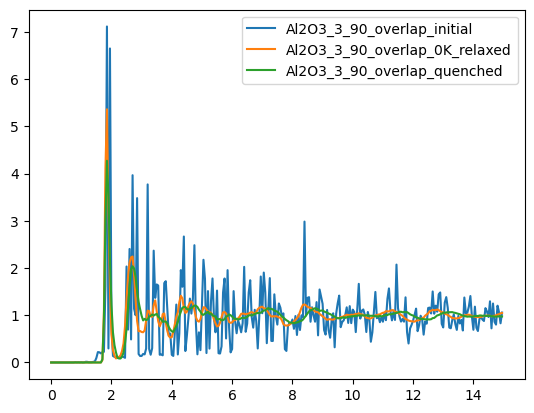

In [34]:
RDF_params = {
    "batch_size" : 25_000,
    "dr" : 0.05,
    "hist_r_max" : 15,
    "skip" : 100,
    "reduced": True, 
}

rdf = RDF(device=device, v=0)
fig, ax = plt.subplots()

gr_3Ds = {}

for f, nm in zip([init_file, relax_file, quench_file], ["init", "relax", "quench"]): 
    atoms = load_xyz(f, v=0)
    
    r, gr_3D = rdf.rdf(
        atoms,
        pbcs=atoms.pbc,
        **RDF_params, 
    )
    r = r.get()
    gr_3D=gr_3D.get()
    gr_3Ds[nm] = gr_3D
    gr_3Ds['r'] = r

    ax.plot(r, gr_3D, label=f.stem)
    
ax.legend() 
plt.show()
    

loading file: Al2O3_3_90_overlap_quenched.xyz
# atoms: 199560
Atoms(symbols='Al79799O119761', pbc=True, cell=[88.84597917112492, 90.52096313660806, 228.25698542633242], id=..., initial_charges=..., masses=..., mmcharges=..., momenta=..., type=...)


  0%|          | 0/3 [00:00<?, ?it/s]

Cell size (A): [ 88.84597917  90.52096314 228.25698543]
Using a max radius of 15 A
Num total atoms in sim = 199560
Skip = 100, so calculating using 1996 atoms as centers
atomic density = 0.109 atoms / A^3
N_max_neighbors:  9220
-- done --
Total time (h:m:s) 0:00:00.05
Center atoms per sec: 39_717.02

Cell size (A): [ 88.84597917  90.52096314 228.25698543]
Using a max radius of 15 A
Reducing dr_ind from 1 -> 0.5


 67%|██████▋   | 2/3 [00:00<00:00,  4.73it/s]

Num total atoms in sim = 199560
Skip = 100, so calculating using 1996 atoms as centers
atomic density = 0.109 atoms / A^3
N_max_neighbors:  9220
-- done --
Total time (h:m:s) 0:00:00.333
Center atoms per sec: 5_988.51

Cell size (A): [ 88.84597917  90.52096314 228.25698543]
Using a max radius of 15 A
Reducing dr_ind from 1 -> 0.5


100%|██████████| 3/3 [00:00<00:00,  4.50it/s]

Num total atoms in sim = 199560
Skip = 100, so calculating using 1996 atoms as centers
atomic density = 0.109 atoms / A^3
N_max_neighbors:  9220
-- done --
Total time (h:m:s) 0:00:00.227
Center atoms per sec: 8_797.75



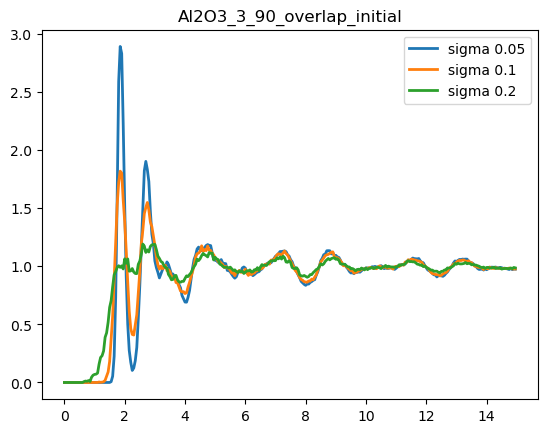

In [36]:
RDF_params = {
    "batch_size" : 25_000,
    "dr" : 0.05,
    "hist_r_max" : 15,
    "skip" : 100,
    "reduced": True, 
}

# sigmas = [0.01, 0.02, 0.03]
sigmas = [0.05, 0.1, 0.2]
# sigmas = [0.01, 0.05, 0.1, 0.2, 0.3, 0.5]

gr_3Dsigmas = {}

rdf = RDF(device=device, v=3)
# atoms2 = load_xyz(init_file, v=3) 
atoms2 = load_xyz(quench_file, v=3) 
for sigma in tqdm(sigmas):
    jitter = np.random.normal(loc=0, scale=sigma, size=atoms2.positions.shape)
    atoms2.positions += jitter
    atoms2.wrap() 

    rs, gr_3D_sigma = rdf.rdf(
        atoms2,
        pbcs=atoms2.pbc,
        **RDF_params, 
    )
    gr_3D_sigma = gr_3D_sigma.get()
    gr_3Dsigmas[f"gr_sigma_{sigma}"] = gr_3D_sigma 

gr_3Dsigmas['r'] = rs.get() 
fig, ax = plt.subplots()
# ax.plot(r, gr_3Dsigmas['init'], label='no jitter')

for sigma in sigmas: 
    ax.plot(gr_3Dsigmas['r'], gr_3Dsigmas[f"gr_sigma_{sigma}"], label=f'sigma {sigma}', lw = 2)
ax.legend()
ax.set_title(init_file.stem)
plt.show()
    

In [ ]:
fig, ax = plt.subplots()
ax.plot(gr_3Ds['r'], gr_3Ds['init']+8, label='initial')
ax.plot(gr_3Ds['r'], gr_3Ds['quench']+5, label='quench')
# ax.plot(gr_3Ds['r'], gr_3Dsigmas['gr_sigma_0.01']+3, label='sigma 0.01')
ax.plot(gr_3Ds['r'], gr_3Dsigmas['gr_sigma_0.05']+2, label='sigma 0.05')
ax.plot(gr_3Ds['r'], gr_3Dsigmas['gr_sigma_0.1']+0, label='sigma 0.1')
ax.plot(gr_3Ds['r'], gr_3Dsigmas['gr_sigma_0.2']-1, label='sigma 0.2')
ax.legend()
ax.set_title(f"Quenched vs initial+jitter | {quench_file.stem}")
ax.set_ylabel("g(r)")
ax.set_xlabel("r (A)")
plt.show()


# Improved orientation mixing with rotations and such 
- use init file
- rotation of random blocks
- BZA spline + vortex operations or gaussians, + normalization 
    - long range variation in displacement 
- last pass do a repulsion check 

loading file: Al2O3_3_90_overlap_quenched.xyz
# atoms: 199560
Atoms(symbols='Al79799O119761', pbc=True, cell=[88.84597917112492, 90.52096313660806, 228.25698542633242], id=..., initial_charges=..., masses=..., mmcharges=..., momenta=..., type=...)
Cell size (A): [ 88.84597917  90.52096314 228.25698543]
Using a max radius of 15 A
Num total atoms in sim = 199560
Skip = 100, so calculating using 1996 atoms as centers
atomic density = 0.109 atoms / A^3
N_max_neighbors:  9220
-- done --
Total time (h:m:s) 0:00:00.282
Center atoms per sec: 7_088.59



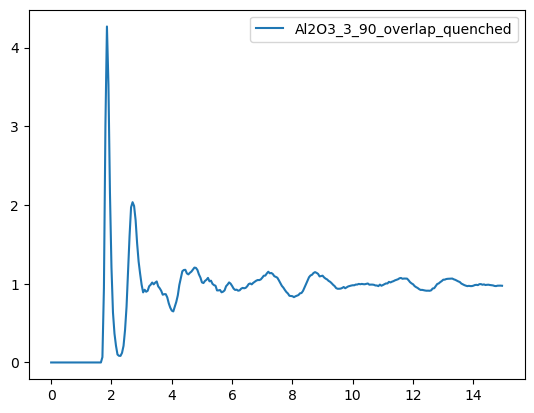

In [4]:
# f = next(tdir.glob("../*crystal.xyz"))
f = quench_file
# f = Path("~/data/distillery/structures/SiO2/nc_seeds/SiO2_nc_10_initial.xyz").expanduser()
# f = Path("~/data/distillery/structures/SiO2/SiO2_amorphous.xyz").expanduser()
atoms = load_xyz(f, v=1)

RDF_params = {
    "batch_size" : 25_000,
    "dr" : 0.05,
    "hist_r_max" : 15,
    "skip" : 100,
    "reduced": True, 
}
rdf = RDF(device=device, v=1)
r, gr_init = rdf.rdf(
        atoms,
        pbcs=atoms.pbc,
        **RDF_params, 
)
gr_init = gr_init.get()
r = r.get()

fig, ax = plt.subplots()
ax.plot(r, gr_init, label=f.stem)
ax.legend() 
plt.show()
    

### NC seeds method

In [5]:
from gas.generation.nc_seeds import load_and_prepare_xyz, add_seeds_to_amorphous_block
from gas.generation.utils import get_nanocrystalline_grains, orient_and_shift_grain, get_voronoi_bisectors, get_cell_info

In [13]:
# cell_data = get_cell_info(init_file)
# f = quench_file
# atoms = load_xyz(f, v=1)

cell_data = {
    "pbc": np.array([True,True,False]),
    "cell_orig": [0,0,0], # atoms.get_cell().array, # atoms.cell, # np.eye(3) * atoms.cell, 
}

starting_block = atoms.copy()
# crystal_cif = Path("../../generation/example_files/mp-149_as_Au.cif")
crystal_cif = Path("~/data/distillery/structures/Al2O3/Al2O3_trigonal_mp-1143.cif").expanduser()
config = {
    "seed_crystal": crystal_cif,  # which crystal to use as a seed grain
    "pbc": (True, True, False),  # pbc of scene
    "min_dist": 8,  # minimum distance between seed centers, in angstroms
    "N_seeds": 128,  # maximum number of seeds to include
    "density": 1/20**3,  # number density of seed centers, in N * angstrom ^ -3
    # "tolerance": 1.0,  # amount of excess space to exclude orig liquid atoms from
    "return_seeds": (
        return_seeds := True
    ),  # also return a scene with just the seed grains
}

if return_seeds:
    block_with_seeds, seeds = add_seeds_to_amorphous_block(starting_block, cell_data, **config)
    # seeds.to_file("SiO_seeds.xyz")
else:
    block_with_seeds = add_seeds_to_amorphous_block(starting_block, cell_data, **config)

# abtem.show_atoms(seeds.ase_atoms)


Sampling nanocrystalline seeds


collisions: 100%|██████████| 128/128 [00:04<00:00, 30.72it/s]


7096


<Axes: xlabel='x [Å]', ylabel='y [Å]'>

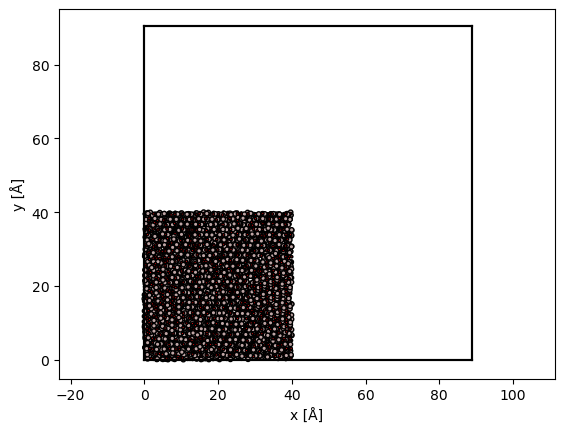

In [7]:

atoms_filt = block_with_seeds.ase_atoms.copy()
a = 40 
c = 40
m = (atoms_filt.positions[:,0] > a) | (atoms_filt.positions[:,1] > a) | (atoms_filt.positions[:,2] > c)
del atoms_filt[m]
print(len(atoms_filt))
abtem.show_atoms(atoms_filt)


Cell size (A): [ 88.84597917  90.52096314 228.25698543]
Using a max radius of 15 A
Reducing dr_ind from 1 -> 0.5
Proceeding with dr_ind of 0.5 despite losing 26 / 2.05e+05 atoms (0.013%)
Num total atoms in sim = 204816
Skip = 100, so calculating using 2049 atoms as centers
atomic density = 0.112 atoms / A^3
N_max_neighbors:  9464
-- done --
Total time (h:m:s) 0:00:01.134
Center atoms per sec: 1_806.80



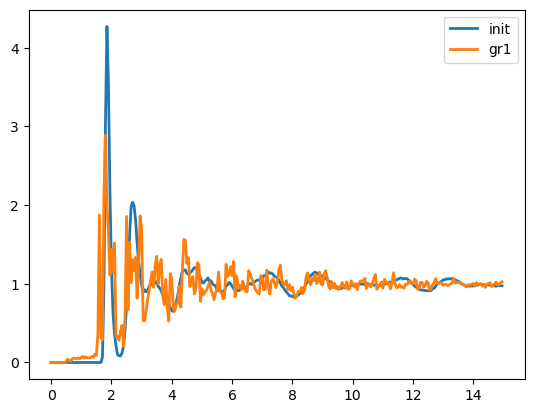

In [9]:
r, gr1 = rdf.rdf(
        block_with_seeds.ase_atoms,
        pbcs=atoms.pbc,
        **RDF_params, 
        dr_ind_min = 0.5, 
)
gr1 = gr1.get()
r = r.get()

fig, ax = plt.subplots()
ax.plot(r, gr_init, label='init', lw=2)
ax.plot(r, gr1, label='gr1', lw=2)
# ax.plot(r, gr1, label='gr1', linestyle='dotted', lw=2)
ax.legend() 
plt.show()
    

## Rotating and replacing same volumes

229 / 229 seeds selected


modifying grains: 100%|██████████| 229/229 [00:01<00:00, 215.63it/s]
static grains: 0it [00:00, ?it/s]


total atoms: mod 178666 | edge: 20894 | sum 199560 | true total 199560 | 
making scene
populating
done
# atoms1:  195442
# atoms2:  195442
Num atoms 195442/199560 = 97.9%
Cell size (A): [ 88.84597917  90.52096314 228.25698543]
Using a max radius of 15 A
Num total atoms in sim = 188058
Skip = 100, so calculating using 1881 atoms as centers
atomic density = 0.102 atoms / A^3
N_max_neighbors:  8690
-- done --
Total time (h:m:s) 0:00:00.038
Center atoms per sec: 48_910.33



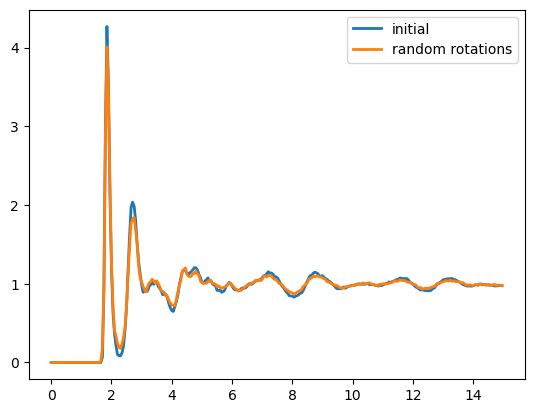

In [21]:
from gas.generation.modify_volume import modify_volume, remove_close_atoms

rng = np.random.default_rng(42)

config = {
    "min_dist": 10,  # minimum distance between seed centers, in angstroms
    "seeds_frac": 1, # 
    "density": 1/20**3,  # number density of seed centers, in N * angstrom ^ -3
    "theta_max": 5, 
}

mod_atoms = modify_volume(
    atoms,
    config, 
    rng=rng,
)

print(f"Num atoms {len(mod_atoms)}/{len(atoms)} = {len(mod_atoms)/len(atoms)*100:.1f}%")
threshold = 0.9 * r[np.argmax(gr_init)]
mod_atoms = remove_close_atoms(mod_atoms, threshold=threshold)

r, gr2 = rdf.rdf(
        mod_atoms,
        pbcs=atoms.pbc,
        **RDF_params, 
        dr_ind_min = 0.5, 
)
gr2 = gr2.get()
r = r.get()
fig, ax = plt.subplots()
ax.plot(r, gr_init, label='initial', lw=2)
ax.plot(r, gr2, label='random rotations', lw=2)
# ax.plot(r, gr2, label='gr2', linestyle='dotted', lw=2)
ax.legend() 
plt.show()


# mod_atoms = modify_volume(
#     mod_atoms,
#     config, 
#     rng=rng,
# )
# mod_atoms = remove_close_atoms(mod_atoms, threshold=threshold)

# r, gr2 = rdf.rdf(
#         mod_atoms,
#         pbcs=atoms.pbc,
#         **RDF_params, 
#         dr_ind_min = 0.5, 
# )
# gr2 = gr2.get()
# r = r.get()
# fig, ax = plt.subplots()
# ax.plot(r, gr_init, label='initial', lw=2)
# ax.plot(r, gr2, label='random rotations', lw=2)
# # ax.plot(r, gr2, label='gr2', linestyle='dotted', lw=2)
# ax.legend() 
# plt.show()


# mod_atoms = modify_volume(
#     mod_atoms,
#     config, 
#     rng=rng,
# )
# mod_atoms = remove_close_atoms(mod_atoms, threshold=threshold)

# r, gr2 = rdf.rdf(
#         mod_atoms,
#         pbcs=atoms.pbc,
#         **RDF_params, 
#         dr_ind_min = 0.5, 
# )
# gr2 = gr2.get()
# r = r.get()
# fig, ax = plt.subplots()
# ax.plot(r, gr_init, label='initial', lw=2)
# ax.plot(r, gr2, label='random rotations', lw=2)
# # ax.plot(r, gr2, label='gr2', linestyle='dotted', lw=2)
# ax.legend() 
# plt.show()

Cell size (A): [ 88.84597917  90.52096314 228.25698543]
Using a max radius of 15 A
Num total atoms in sim = 142511
Skip = 100, so calculating using 1426 atoms as centers
atomic density = 0.0776 atoms / A^3
N_max_neighbors:  6584
-- done --
Total time (h:m:s) 0:00:00.048
Center atoms per sec: 29_635.94



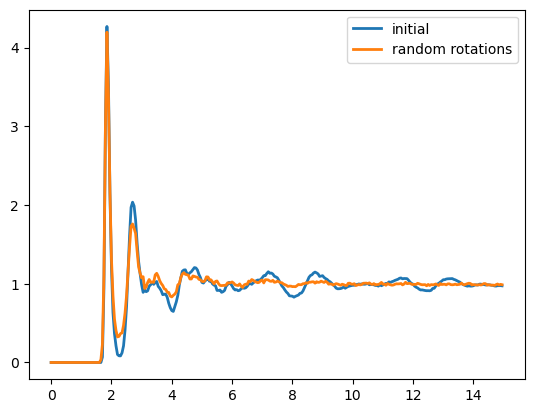

In [ ]:
r, gr2 = rdf.rdf(
        mod_atoms,
        pbcs=atoms.pbc,
        **RDF_params, 
        dr_ind_min = 0.5, 
)
gr2 = gr2.get()
r = r.get()

fig, ax = plt.subplots()
ax.plot(r, gr_init, label='initial', lw=2)
ax.plot(r, gr2, label='random rotations', lw=2)
# ax.plot(r, gr2, label='gr2', linestyle='dotted', lw=2)
ax.legend() 
plt.show()

Cell size (A): [ 88.84597917  90.52096314 228.25698543]
Using a max radius of 15 A
Num total atoms in sim = 157711
Skip = 100, so calculating using 1578 atoms as centers
atomic density = 0.0859 atoms / A^3
N_max_neighbors:  7288
-- done --
Total time (h:m:s) 0:00:00.035
Center atoms per sec: 44_560.39



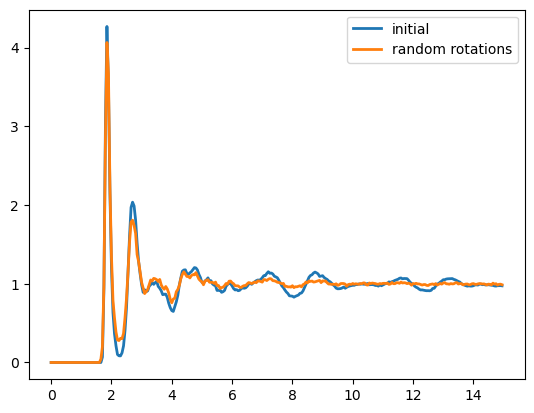

In [406]:
r, gr2 = rdf.rdf(
        mod_atoms,
        pbcs=atoms.pbc,
        **RDF_params, 
        dr_ind_min = 0.5, 
)
gr2 = gr2.get()
r = r.get()

fig, ax = plt.subplots()
ax.plot(r, gr_init, label='initial', lw=2)
ax.plot(r, gr2, label='random rotations', lw=2)
# ax.plot(r, gr2, label='gr2', linestyle='dotted', lw=2)
ax.legend() 
plt.show()
    

Cell size (A): [ 88.84597917  90.52096314 228.25698543]
Using a max radius of 15 A
Num total atoms in sim = 176984
Skip = 100, so calculating using 1770 atoms as centers
atomic density = 0.0964 atoms / A^3
N_max_neighbors:  8178
-- done --
Total time (h:m:s) 0:00:00.037
Center atoms per sec: 47_219.78



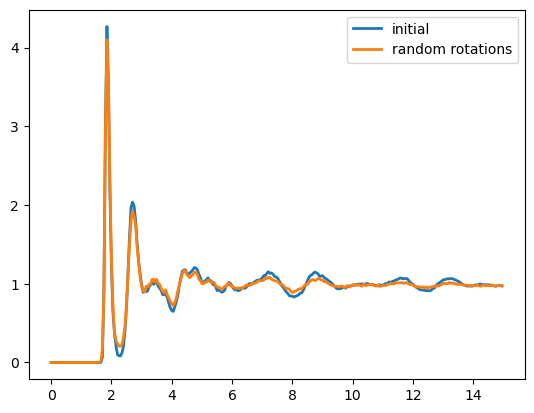

In [404]:
r, gr2 = rdf.rdf(
        mod_atoms,
        pbcs=atoms.pbc,
        **RDF_params, 
        dr_ind_min = 0.5, 
)
gr2 = gr2.get()
r = r.get()

fig, ax = plt.subplots()
ax.plot(r, gr_init, label='initial', lw=2)
ax.plot(r, gr2, label='random rotations', lw=2)
# ax.plot(r, gr2, label='gr2', linestyle='dotted', lw=2)
ax.legend() 
plt.show()
    

# voronoi stuff 

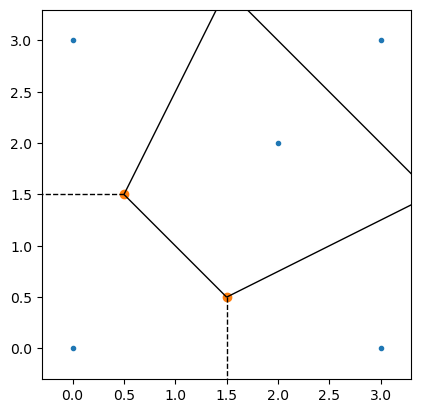

In [ ]:
from scipy.spatial import Voronoi, voronoi_plot_2d
points = [
    [2, 2]
    # [2, 2, 2]
]
# points = [ [1, 1], [1, 2], [2, 1], [2, 2]]
border = [
    [0,0], [0,3], [3,0], [3,3]
    # [0, 0,0], [0, 0,3], [0, 3,0], [0, 3,3], [3, 0,0], [3, 0,3], [3, 3,0], [3, 3,3],
    
]

points += border 

vor = Voronoi(points)
fig, ax= plt.subplots()
voronoi_plot_2d(vor, ax=ax)
ax.set_aspect(1)
plt.show()

In [ ]:
vor

In [ ]:
ybound, xbound = 3, 3
vor.vertices[:,0] = np.clip(vor.vertices[:,0], 0, ybound)
vor.vertices[:,1] = np.clip(vor.vertices[:,1], 0, xbound)

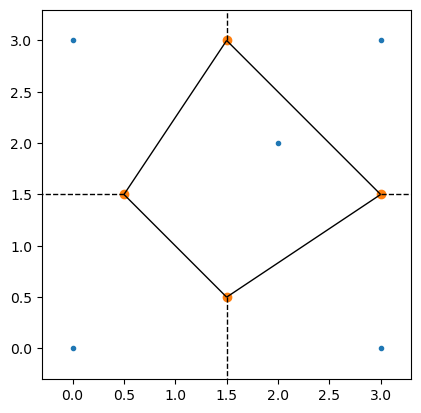

In [ ]:
fig, ax= plt.subplots()
voronoi_plot_2d(vor, ax=ax)
ax.set_aspect(1)
plt.show()

In [ ]:
center = vor.points.mean(axis=0)
ptp_bound = np.ptp(vor.points, axis=0)

finite_segments = [] 
infinite_segments = [] 
for pointidx, simplex in zip(vor.ridge_points, vor.ridge_vertices):
    simplex = np.asarray(simplex)
    if np.all(simplex >= 0):
        finite_segments.append(vor.vertices[simplex])
    else:
        i = simplex[simplex >= 0][0]  # finite end Voronoi vertex

        t = vor.points[pointidx[1]] - vor.points[pointidx[0]]  # tangent
        t /= np.linalg.norm(t)
        n = np.array([-t[1], t[0]])  # normal

        midpoint = vor.points[pointidx].mean(axis=0)
        direction = np.sign(np.dot(midpoint - center, n)) * n
        if (vor.furthest_site):
            direction = -direction
        far_point = vor.vertices[i] + direction * ptp_bound.max() 

        infinite_segments.append([vor.vertices[i], far_point])


In [ ]:
len(points)

5

In [ ]:
center = vor.points.mean(axis=0)
ptp_bound = np.ptp(vor.points, axis=0)

central_vertices = [] 
edge_vertices = [] 

for i in range(len(points)): 
    cpoint = vor.points[i] 
    region = np.array(vor.regions[vor.point_region[i]])
    print(cpoint, region)

    if np.all(region>=0): 
        vertices = vor.vertices[region]
        central_vertices.append(vertices)
    else: 
        ridge_inds = np.where(vor.ridge_points == i)[0]
        ridge_vertices = np.array(vor.ridge_vertices)[ridge_inds]
        ridge_points = np.array(vor.ridge_points)[ridge_inds]
        print(ridge_vertices)
        vertices = vor.vertices[np.unique(ridge_vertices[ridge_vertices>=0])].tolist()
        vertices.append(cpoint.tolist()) 
        for pointidx, simplex in zip(ridge_points, ridge_vertices): 
            # print("simplex: ", simplex)
            # print("pointidx: ", pointidx)
            if np.any(simplex < 0): 
                i = simplex[simplex >= 0][0]  # finite end Voronoi vertex

                t = vor.points[pointidx[1]] - vor.points[pointidx[0]]  # tangent
                t /= np.linalg.norm(t)
                n = np.array([-t[1], t[0]])  # normal

                midpoint = vor.points[pointidx].mean(axis=0)
                direction = np.sign(np.dot(midpoint - center, n)) * n
                if (vor.furthest_site):
                    direction = -direction
                far_point = vor.vertices[i] + direction * ptp_bound.max()
                far_point[0] = np.clip(far_point[0], 0, ybound)
                far_point[1] = np.clip(far_point[1], 0, xbound)
                # print(f"midpoint: {midpoint} direction {direction} far point: ", far_point)
                if far_point.tolist() not in vertices: 
                    vertices.append(far_point.tolist()) 
        edge_vertices.append(np.array(vertices))
        
    print(vertices)
    print()

all_vertices = central_vertices + edge_vertices
# central_vertices = np.array(central_vertices)
# edge_vertices = np.array(edge_vertices)

[2. 2.] [3 1 0 2]
[[3.  1.5]
 [1.5 0.5]
 [0.5 1.5]
 [1.5 3. ]]

[0. 0.] [ 1 -1  0]
[[ 0  1]
 [-1  0]
 [-1  1]]
[[0.5, 1.5], [1.5, 0.5], [0.0, 0.0], [0.0, 1.5], [1.5, 0.0]]

[0. 3.] [ 2 -1  0]
[[ 0  2]
 [-1  2]
 [-1  0]]
[[0.5, 1.5], [1.5, 3.0], [0.0, 3.0], [0.0, 1.5]]

[3. 0.] [ 3 -1  1]
[[ 1  3]
 [-1  1]
 [-1  3]]
[[1.5, 0.5], [3.0, 1.5], [3.0, 0.0], [1.5, 0.0]]

[3. 3.] [ 3 -1  2]
[[ 2  3]
 [-1  2]
 [-1  3]]
[[1.5, 3.0], [3.0, 1.5], [3.0, 3.0]]



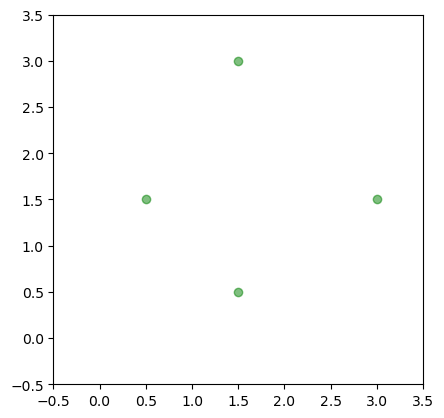

In [ ]:
i = 0
fig, ax = plt.subplots()
# ax.scatter(vor.points[inds][:,1], vor.points[inds][:,0], c='b')
# ax.scatter(central_vertices[:,1], central_vertices[:,0], c='b')
# ax.scatter(vor.vertices[inds][:,1], vor.vertices[inds][:,0], c='r')
ax.scatter(all_vertices[i][:,1], all_vertices[i][:,0], c='g', alpha=0.5)

ax.set_xlim([-0.5, 3.5])
ax.set_ylim([-0.5, 3.5])
ax.set_aspect(1)
plt.show()

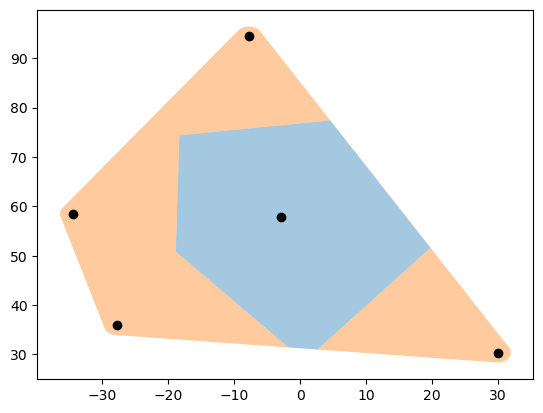

In [ ]:
from shapely.ops import polygonize,unary_union
from shapely.geometry import LineString, MultiPolygon, MultiPoint, Point
# points = [[-30.0, 30.370371], [-27.777777, 35.925926], [-34.444443, 58.51852], [-2.9629631, 57.777779], [-17.777779, 75.185181], [-29.25926, 58.148151], [-11.111112, 33.703705], [-11.481482, 40.0], [-27.037037, 40.0], [-7.7777777, 94.444443], [-2.2222223, 122.22222], [-20.370371, 106.66667], [1.1111112, 125.18518], [-6.2962961, 128.88889], [6.666667, 133.7037], [11.851852, 136.2963], [8.5185184, 140.74074], [20.370371, 92.962959], [17.777779, 114.81482], [12.962962, 97.037041], [13.333334, 127.77778], [22.592592, 120.37037], [16.296295, 127.77778], [11.851852, 50.740742], [20.370371, 54.814816], [19.25926, 47.40741], [32.59259, 122.96296], [20.74074, 130.0], [24.814816, 84.814819], [26.296295, 91.111107], [56.296295, 131.48149], [60.0, 141.85185], [32.222221, 136.66667], [53.703705, 147.03703], [87.40741, 196.2963], [34.074074, 159.62964], [34.444443, -2.5925925], [36.666668, -1.8518518], [34.074074, -7.4074073], [35.555557, -18.888889], [76.666664, -39.629627], [35.185184, -37.777779], [25.185184, 14.074074], [42.962959, 32.962963], [35.925926, 9.2592592], [52.222221, 77.777779], [57.777779, 92.222221], [47.037041, 92.59259], [82.222221, 54.074074], [48.888889, 24.444445], [35.925926, 47.777779], [50.740742, 69.259254], [51.111111, 51.851849], [56.666664, -12.222222], [117.40741, -4.4444447], [59.629631, -5.9259262], [66.666664, 134.07408], [91.481483, 127.40741], [66.666664, 141.48149], [53.703705, 4.0740738], [85.185181, 11.851852], [69.629631, 0.37037039], [68.518517, 99.259262], [75.185181, 100.0], [70.370369, 113.7037], [74.444443, 82.59259], [82.222221, 93.703697], [72.222221, 84.444443], [77.777779, 167.03703], [88.888893, 168.88889], [73.703705, 178.88889], [87.037041, 123.7037], [78.518517, 97.037041], [95.555557, 52.962959], [85.555557, 57.037041], [90.370369, 23.333332], [100.0, 28.51852], [88.888893, 37.037037], [87.037041, -42.962959], [89.259262, -24.814816], [93.333328, 7.4074073], [98.518517, 5.185185], [92.59259, 1.4814816], [85.925919, 153.7037], [95.555557, 154.44444], [92.962959, 150.0], [97.037041, 95.925919], [106.66667, 115.55556], [92.962959, 114.81482], [108.88889, 56.296295], [97.777779, 50.740742], [94.074081, 89.259262], [96.666672, 91.851852], [102.22222, 77.777779], [107.40741, 40.370369], [105.92592, 29.629629], [105.55556, -46.296295], [118.51852, -47.777779], [112.22222, -43.333336], [112.59259, 25.185184], [115.92592, 27.777777], [112.59259, 31.851852], [107.03704, -36.666668], [118.88889, -32.59259], [114.07408, -25.555555], [115.92592, 85.185181], [105.92592, 18.888889], [121.11111, 14.444445], [129.25926, -28.51852], [127.03704, -18.518518], [139.25926, -12.222222], [141.48149, 3.7037036], [137.03703, -4.814815], [153.7037, -26.666668], [-2.2222223, 5.5555558], [0.0, 9.6296301], [10.74074, 20.74074], [2.2222223, 54.074074], [4.0740738, 50.740742], [34.444443, 46.296295], [11.481482, 1.4814816], [24.074076, -2.9629631], [74.814819, 79.259254], [67.777779, 152.22223], [57.037041, 127.03704], [89.259262, 12.222222]]
points = [[30.0, 30.370371], [-27.777777, 35.925926], [-34.444443, 58.51852], [-2.9629631, 57.777779],  [-7.7777777, 94.444443]]

# points = [ [1, 1], [1, 2], [2, 1], [2, 2]]
# border = [
#     [0,0], [0,3], [3,0], [3,3]
# ]
# points += border 

points = np.array(points)
vor = Voronoi(points)
lines = [
    LineString(vor.vertices[line])
    for line in vor.ridge_vertices if -1 not in line
]

convex_hull = MultiPoint([Point(i) for i in points]).convex_hull.buffer(2)
result = MultiPolygon(
    [poly.intersection(convex_hull) for poly in polygonize(lines)])
result = MultiPolygon(
    [p for p in result.geoms]
    + [p for p in convex_hull.difference(unary_union(result)).geoms])

plt.plot(points[:,0], points[:,1], 'ko')
for r in result.geoms:
    plt.fill(*zip(*np.array(list(
        zip(r.boundary.coords.xy[0][:-1], r.boundary.coords.xy[1][:-1])))),
        alpha=0.4)
plt.show()

In [ ]:

# Define bounding box limits
bounding_box = np.array([[0, 10], [0, 10], [0, 10]])  # Cube from (0,0,0) to (10,10,10)

# Given points
points = np.array([[2,2,2], [2,2,8], [2,8,4], [2,8,8], [8,2,2], [8,2,8], [8,8,2], [8,8,8]])
# points = np.array([[2,2,2], [8,2,2], [2,8,8], [8,8,8]])

# Compute Voronoi tessellation
vor = Voronoi(points)

def plane_box_intersection(plane_point, plane_normal, bbox):
    """
    Compute intersections of a plane (defined by a point and normal) with a 3D bounding box.
    Returns a list of intersection points.
    """
    intersections = []
    min_x, max_x = bbox[0]
    min_y, max_y = bbox[1]
    min_z, max_z = bbox[2]

    # Define 6 bounding box planes
    box_planes = [
        ((min_x, 0, 0), (1, 0, 0)),  # X = min_x
        ((max_x, 0, 0), (-1, 0, 0)), # X = max_x
        ((0, min_y, 0), (0, 1, 0)),  # Y = min_y
        ((0, max_y, 0), (0, -1, 0)), # Y = max_y
        ((0, 0, min_z), (0, 0, 1)),  # Z = min_z
        ((0, 0, max_z), (0, 0, -1))  # Z = max_z
    ]

    for (p0, n) in box_planes:
        # Solve for intersection t where (p - p0) ⋅ n = 0
        denom = np.dot(plane_normal, n)
        if abs(denom) > 1e-6:  # Avoid division by zero (parallel planes)
            t = np.dot(np.array(p0) - plane_point, n) / denom
            intersection = plane_point + t * plane_normal
            
            # Check if the intersection is within the bounding box
            if (min_x <= intersection[0] <= max_x and 
                min_y <= intersection[1] <= max_y and 
                min_z <= intersection[2] <= max_z):
                intersections.append(intersection)

    return intersections

def get_voronoi_cells(vor, bbox):
    """
    Compute the Voronoi cells clipped to the bounding box.
    Returns a dictionary mapping each input point to its bounding polyhedron.
    """
    voronoi_cells = {}

    for i, point in enumerate(vor.points):
        region_index = vor.point_region[i]
        region = vor.regions[region_index]

        if -1 in region:  # Region has infinite ridges
            finite_vertices = [vor.vertices[v] for v in region if v != -1]
            for (p1, p2), ridge_vertices in zip(vor.ridge_points, vor.ridge_vertices):
                if -1 in ridge_vertices and (p1 == i or p2 == i):
                    # Find finite vertex and compute direction
                    finite_vertex = [vor.vertices[v] for v in ridge_vertices if v != -1][0]
                    voronoi_center = vor.points[[p1, p2]].mean(axis=0)
                    direction = finite_vertex - voronoi_center
                    direction /= np.linalg.norm(direction)  # Normalize

                    # Compute intersections with bounding box
                    clipped_points = plane_box_intersection(finite_vertex, direction, bbox)
                    finite_vertices.extend(clipped_points)

            voronoi_cells[tuple(point)] = np.array(finite_vertices)
        else:  # Fully finite cell
            finite_vertices = [vor.vertices[v] for v in region]
            voronoi_cells[tuple(point)] = np.array(finite_vertices)

    return voronoi_cells

# Compute the Voronoi cells clipped to the bounding box
voronoi_cells = get_voronoi_cells(vor, bounding_box)

# Print results
for center, cell_vertices in voronoi_cells.items():
    print(f"Voronoi cell around {center}:")
    print(cell_vertices)


Voronoi cell around (np.float64(2.0), np.float64(2.0), np.float64(2.0)):
[[ 5.          5.          3.        ]
 [ 5.          4.33333333  5.        ]
 [ 0.          5.44444444  1.66666667]
 [10.          3.22222222  8.33333333]
 [ 5.          0.44444444  0.        ]
 [ 5.          8.22222222 10.        ]]
Voronoi cell around (np.float64(2.0), np.float64(2.0), np.float64(8.0)):
[[ 5.          4.33333333  5.        ]
 [ 5.          5.          6.        ]
 [ 5.          8.22222222  0.        ]
 [ 5.          0.44444444 10.        ]
 [ 0.          5.44444444  6.66666667]
 [10.          3.22222222  3.33333333]]
Voronoi cell around (np.float64(2.0), np.float64(8.0), np.float64(4.0)):
[[ 5.          5.          3.        ]
 [ 5.          4.33333333  5.        ]
 [ 5.66666667  5.          5.        ]
 [ 5.          5.          6.        ]
 [ 0.          5.44444444  6.66666667]
 [10.          3.22222222  3.33333333]
 [ 0.          5.44444444  1.66666667]
 [10.          3.22222222  8.33333333]

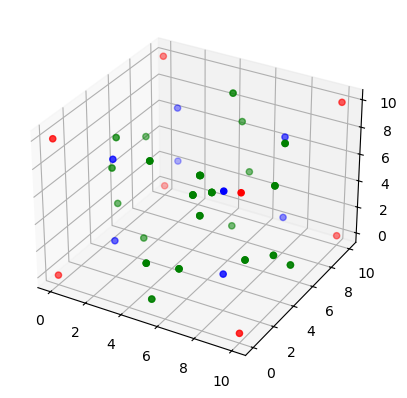

In [ ]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

a = 10 
bbox = np.array([
    [0,0,0],
    [0,0,a],
    [0,a,0],
    [0,a,a],
    [a,0,0],
    [a,0,a],
    [a,a,0],
    [a,a,a],
])

ax.scatter(bbox[:,0], bbox[:,1], bbox[:,2], c='r')
ax.scatter(points[:,0], points[:,1], points[:,2], c='b')

for center, cell_vertices in voronoi_cells.items():
    ax.scatter(cell_vertices[:,0], cell_vertices[:,1], cell_vertices[:,2], c='g')



plt.show()

In [ ]:
vor.vertices

array([[5.        , 5.        , 3.        ],
       [5.        , 4.33333333, 5.        ],
       [5.66666667, 5.        , 5.        ],
       [5.        , 5.        , 6.        ]])